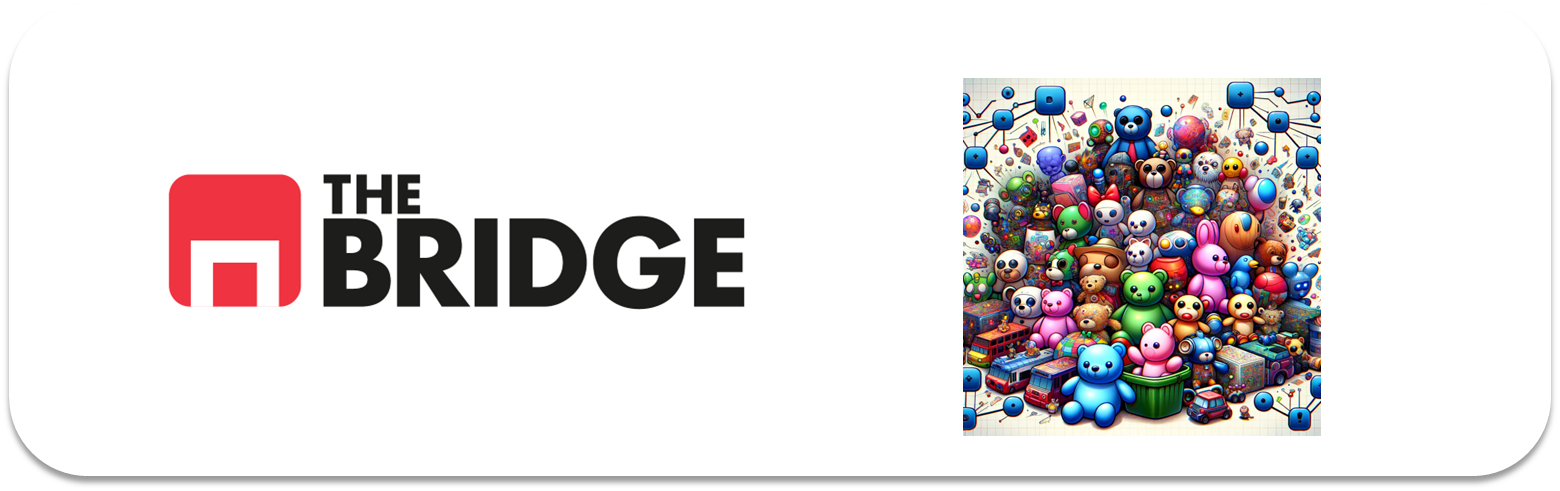

## PRACTICA OBLIGATORIA: **K-Means Clustering**

* La práctica obligatoria de esta unidad consiste en un ejercicio de modelado no supervisado sobre imágenes para practicar con el algoritmo k-means. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook

In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_olivetti_faces
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report



## **#1**

Vamos a trabajar con un dataset también entre los "clásicos" (aunque a veces menos conocido) que es el de rostros Olivetti. Este dataset contiene 400 imágenes en escala de grises de 64 × 64 píxeles de rostros.   


Como en otros datasets de imágenes, estás están "aplanadas" de forma que cada pixel es una feature y por cada imagen hay $64\times 64 = 4096$ features.  

Se fotografiaron 40 personas diferentes (10 veces cada una) y esas fotografías se recogen en el dataset.  

La tarea habitual es entrenar un modelo que pueda predecir qué persona está representada en cada imagen, pero nosotros lo vamos a hacer de forma no supervisada. 



### #1.1


Carga el conjunto de datos usando la función `sklearn.datasets.fetch_olivetti_faces()`. Recuerda que se carga un "diccionario". Muestra su descripción acudiendo a la clave "DESCR".

In [35]:
# Cargamos el dataset
rostros = fetch_olivetti_faces(shuffle=True, random_state=42)

# Accedemos a la descripción a través de la clave 'DESCR'
print(rostros.DESCR)

# Guardamos los datos en variables para trabajar cómodamente
X = rostros.data      
y = rostros.target    

.. _olivetti_faces_dataset:

The Olivetti faces dataset
--------------------------

`This dataset contains a set of face images`_ taken between April 1992 and
April 1994 at AT&T Laboratories Cambridge. The
:func:`sklearn.datasets.fetch_olivetti_faces` function is the data
fetching / caching function that downloads the data
archive from AT&T.

.. _This dataset contains a set of face images: https://cam-orl.co.uk/facedatabase.html

As described on the original website:

    There are ten different images of each of 40 distinct subjects. For some
    subjects, the images were taken at different times, varying the lighting,
    facial expressions (open / closed eyes, smiling / not smiling) and facial
    details (glasses / no glasses). All the images were taken against a dark
    homogeneous background with the subjects in an upright, frontal position
    (with tolerance for some side movement).

**Data Set Characteristics:**

=================   =====================
Classes              

### #1.2 

Aunque no lo vas a usar hasta el final de la práctica, muestra el target. Luego cargalo todo en un mismo dataframe (tendrás que añadir el target) y obtén otro dataset con todas las imagenes reordenadas aleatoriamente (emplea por ejemplo el método `sample` del dataframe o el método que tú quieras)

In [36]:
print("Target original:", rostros.target)

# Crear el DataFrame con las características 
# Cada columna representará un píxel 
df = pd.DataFrame(X)

#Añadir la columna 'target' al DataFrame
df['target'] = y

#nuevo dataset con las imágenes reordenadas aleatoriamente
df_reordenado = df.sample(frac=1, random_state=42).reset_index(drop=True)

# Mostramos las primeras filas para verificar
print("\nPrimeras filas del dataset reordenado:")
print(df_reordenado.head())

Target original: [20 28  3 21  9  8 32  9 26 12  0 36  5  7 13  4 27 37 23 38  7  1 39 27
  0 39 11 22 26 10 39 19 26  5 23 11 11 34 15 14 38  5  7  2  8 38 14 18
  2 17  4 32 33  7 37  3 22 17  3 15 12 29 25  7 10  3 35 26 39  7 32 14
  0  4 38 24 22 36 17 28  0  1 20 25 27  6 24 30 10  9 23 33 11 22 18 31
 37 38 23  7 24 11  1  6 15  0  1 13 35 34 13 38 29 38 29  6  7 28 30 28
 15 10  1 34  2 17 35 33 16 24 31 14 25 17 11 19 22 26 21 30  3 13 29 15
 19 28  5 11 16 36  0 33 27 15  1 19 10  8 31 39 37 20 28 16 35  8 37 16
 14 22  9  6 12  9 14 32  9 23  6  2  3 14 12 18  6 19 32 21 31 19 12 14
 37  8 33 34 33 35 33 30 18 20 28 21 28 12  3  1 32 18 22 11 17 32 29 11
 36 27 38 28 36 16 25 13 15 19 19 39  0 20 11 23 23  2 12 35 22 36 37 35
 37 12  7 32  2  8 38 10 24 29 13 24 18 29  4 36  6  8 24 18 15  1  3  2
 17 14 31 27 22  9  5 24 29 30 17  4 31 20 25 33  0 25 35 10 22 34 21 17
  9 21  6  4  3 26 20 35  2 31 23 26 28 16 37 13  6 13 12  0  6 30  1 15
  4 36 32 21 27 34 23 20 21 29 36 

### #1.3

Vamos a dividir en train y test, pero OJO RECUERDA QUE EN LOS PROBLEMAS NO SUPERVISADOS NO HAY SPLIT (porque no hay target), aquí lo hacemos para poder comparar posteriormente el clustering con la clasificación (ya que es uan práctica formativa).

Por tanto, divídelo en un conjunto de entrenamiento, un conjunto de validación y un conjunto de pruebas (80-10-10). Dado que el conjunto de datos es bastante pequeño, emplea un muestreo estratificado para asegurarse de que haya el mismo número de imágenes por persona en cada conjunto (estratificando por la columna que contenga el target)

NOTA: No hemos hecho hasta ahora la separación en tres sets, investiga por tu cuenta o bien haz primero un split 90-10 y luego otro split 89-11 sobre el de 80 (para que de los números aproximados), por ejemplo.

In [37]:
# Separamos primero en Train (80%) y una parte Temporal (20%)
df_train, df_temp = train_test_split(
    df_reordenado, 
    test_size=0.20, 
    random_state=42, 
    stratify=df_reordenado['target']
)

# Ahora dividimos ese 20% temporal a la mitad para obtener Validation (10%) y Test (10%)
# Al dividir 0.5 de 0.2, nos queda 0.1 del total original
df_val, df_test = train_test_split(
    df_temp, 
    test_size=0.50, 
    random_state=42, 
    stratify=df_temp['target']
)

# Comprobación de tamaños
print(f"Total imágenes: {len(df_reordenado)}")
print(f"Entrenamiento (80%): {len(df_train)}")
print(f"Validación (10%): {len(df_val)}")
print(f"Pruebas (10%): {len(df_test)}")

# Verificamos la estratificación rápida
print("\nEjemplo de distribución en Test (debería haber 1 imagen por persona si hay 40 personas):")
print(df_test['target'].value_counts().head(5))

Total imágenes: 400
Entrenamiento (80%): 320
Validación (10%): 40
Pruebas (10%): 40

Ejemplo de distribución en Test (debería haber 1 imagen por persona si hay 40 personas):
target
3     1
1     1
4     1
5     1
26    1
Name: count, dtype: int64


#1.4
Crea los pares X,y para train, validation y test.

In [38]:
# Definimos las X (píxeles) eliminando la columna 'target'
# Definimos las y (etiquetas) seleccionando solo la columna 'target'

# Conjunto de Entrenamiento
X_train = df_train.drop(columns=['target']).values
y_train = df_train['target'].values

# Conjunto de Validación
X_val = df_val.drop(columns=['target']).values
y_val = df_val['target'].values

# Conjunto de Pruebas (Test)
X_test = df_test.drop(columns=['target']).values
y_test = df_test['target'].values

# Verificación de dimensiones
print(f"X_train shape: {X_train.shape}")
print(f"X_val shape:   {X_val.shape}")
print(f"X_test shape:  {X_test.shape}")

X_train shape: (320, 4096)
X_val shape:   (40, 4096)
X_test shape:  (40, 4096)


Utiliza la siguiente función para visualizar alguna de las caras (observa que tienes que dar la X y la y, usa iloc en ambos datasets)

In [39]:
def plot_faces(faces, labels, n_cols=5):
    faces = faces.reshape(-1, 64, 64)
    n_rows = (len(faces) - 1) // n_cols + 1
    plt.figure(figsize=(n_cols, n_rows * 1.1))
    for index, (face, label) in enumerate(zip(faces, labels)):
        plt.subplot(n_rows, n_cols, index + 1)
        plt.imshow(face, cmap="gray")
        plt.axis("off")
        plt.title(label)
    plt.show()

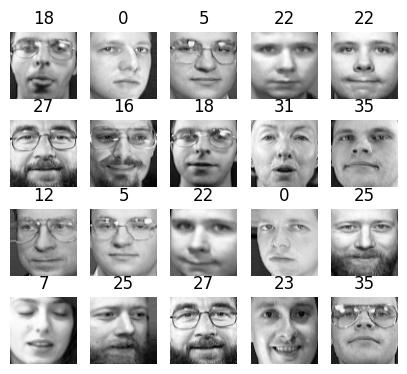

In [40]:
X_sample = df_reordenado.iloc[:20, :-1].values
y_sample = df_reordenado.iloc[:20, -1].values

plot_faces(X_sample, y_sample)

### #1.5

Para acelerar las cosas, reduciremos la dimensionalidad de los datos utilizando PCA (técnica que veremos en el siguiente sprint). Modifica la siguiente celda de forma que las X se correspondan con las que has utilizado en el ejercicio anterior.

In [41]:
from sklearn.decomposition import PCA

# Configuramos PCA para mantener el 99% de la varianza
pca = PCA(0.99, random_state=42)

# Ajustamos y transformamos el conjunto de entrenamiento
X_train_pca = pca.fit_transform(X_train)

# Transformamos validación y test usando el "conocimiento" extraído de train
X_val_pca = pca.transform(X_val)
X_test_pca = pca.transform(X_test)

# Mostramos cuántas componentes han sido necesarias para llegar al 99%
print(f"Número de componentes principales: {pca.n_components_}")

Número de componentes principales: 220


### 1.6

Aquí viene la parte del león. A continuación, agrupa las imágenes utilizando K-Means sobre el dataset de train reducido en el ejercicio anterior. Emplea el método del máximo de score de silueta para obtener el mejor k, probando con K de 5 en 5 hasta 150. ¿Cuál es el k que proporciona el mejor score de silueta? NOTA: Emplea todas las features (no hace falta seleccionar, y ya están escaladas entre 0 y 1)

Iniciando búsqueda del k óptimo...
K=5 -> Silhouette Score: 0.1114
K=10 -> Silhouette Score: 0.0990
K=15 -> Silhouette Score: 0.0993
K=20 -> Silhouette Score: 0.1177
K=25 -> Silhouette Score: 0.1369
K=30 -> Silhouette Score: 0.1404
K=35 -> Silhouette Score: 0.1542
K=40 -> Silhouette Score: 0.1571
K=45 -> Silhouette Score: 0.1660
K=50 -> Silhouette Score: 0.1656
K=55 -> Silhouette Score: 0.1738
K=60 -> Silhouette Score: 0.1818
K=65 -> Silhouette Score: 0.1859
K=70 -> Silhouette Score: 0.1946
K=75 -> Silhouette Score: 0.1989
K=80 -> Silhouette Score: 0.1989
K=85 -> Silhouette Score: 0.2120
K=90 -> Silhouette Score: 0.2102
K=95 -> Silhouette Score: 0.2143
K=100 -> Silhouette Score: 0.2167
K=105 -> Silhouette Score: 0.2170
K=110 -> Silhouette Score: 0.2222
K=115 -> Silhouette Score: 0.2143
K=120 -> Silhouette Score: 0.2073
K=125 -> Silhouette Score: 0.2162
K=130 -> Silhouette Score: 0.2145
K=135 -> Silhouette Score: 0.2174
K=140 -> Silhouette Score: 0.2269
K=145 -> Silhouette Score: 0.2187

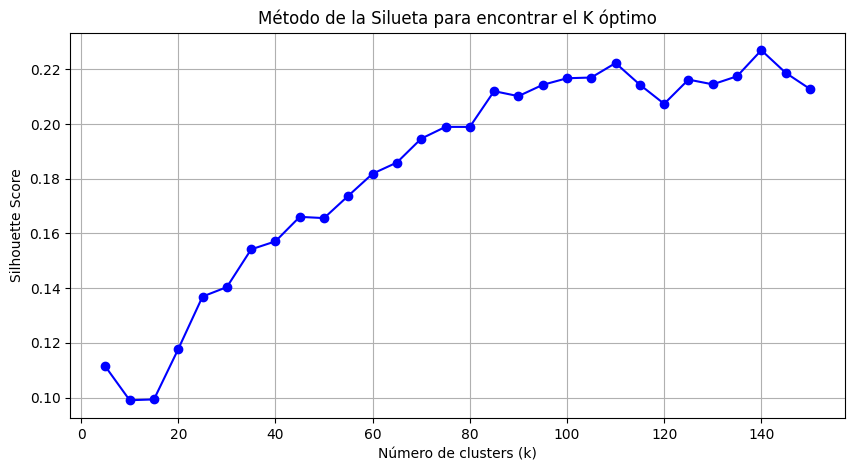

In [42]:

# Listas para almacenar los resultados
k_values = range(5, 155, 5)
silhouette_scores = []
best_k = -1
max_silhouette = -1

print("Iniciando búsqueda del k óptimo...")

for k in k_values:
    # Entrenamos el modelo con el k actual
    # random_state asegura que los resultados sean reproducibles
    kmeans = KMeans(n_clusters=k, n_init=10, random_state=42)
    kmeans.fit(X_train_pca)
    
    # Calculamos el score de silueta
    score = silhouette_score(X_train_pca, kmeans.labels_)
    silhouette_scores.append(score)
    
    print(f"K={k} -> Silhouette Score: {score:.4f}")
    
    # Actualizamos el mejor k si el score actual es el máximo
    if score > max_silhouette:
        max_silhouette = score
        best_k = k

print("-" * 30)
print(f"El mejor valor de K es {best_k} con un score de {max_silhouette:.4f}")

# Visualización opcional para ver la tendencia
plt.figure(figsize=(10, 5))
plt.plot(k_values, silhouette_scores, 'bo-')
plt.xlabel('Número de clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Método de la Silueta para encontrar el K óptimo')
plt.grid(True)
plt.show()

### #1.7

Repite el ejercio anterior empleando ahora el método del codo de Inercia. ¿Sale algo más concluyente o que refuerce el anterior resultado?

Calculando inercias para el método del codo...
K=5 -> Inercia: 16904.27
K=10 -> Inercia: 14781.61
K=15 -> Inercia: 13388.74
K=20 -> Inercia: 12163.08
K=25 -> Inercia: 11167.50
K=30 -> Inercia: 10430.15
K=35 -> Inercia: 9495.45
K=40 -> Inercia: 8932.03
K=45 -> Inercia: 8413.95
K=50 -> Inercia: 7947.36
K=55 -> Inercia: 7418.54
K=60 -> Inercia: 6998.13
K=65 -> Inercia: 6604.85
K=70 -> Inercia: 6274.95
K=75 -> Inercia: 5902.97
K=80 -> Inercia: 5641.77
K=85 -> Inercia: 5312.48
K=90 -> Inercia: 5019.21
K=95 -> Inercia: 4763.97
K=100 -> Inercia: 4514.81
K=105 -> Inercia: 4261.52
K=110 -> Inercia: 4054.47
K=115 -> Inercia: 3832.51
K=120 -> Inercia: 3679.86
K=125 -> Inercia: 3467.54
K=130 -> Inercia: 3292.74
K=135 -> Inercia: 3095.19
K=140 -> Inercia: 2894.01
K=145 -> Inercia: 2750.11
K=150 -> Inercia: 2588.90


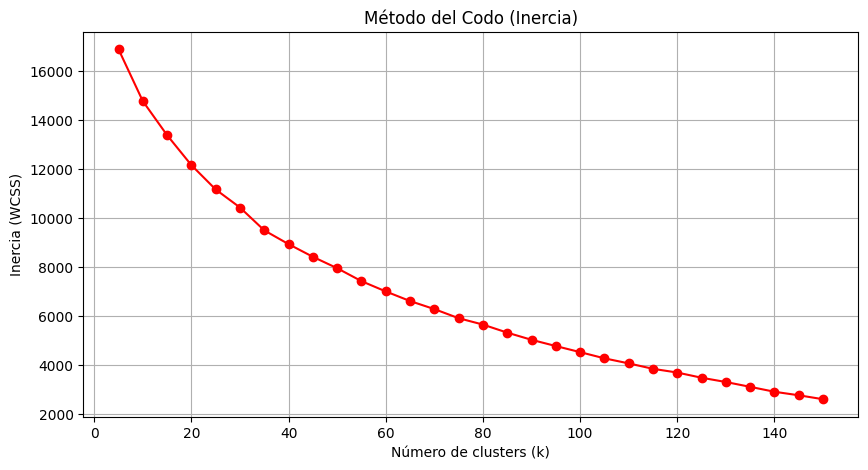

In [43]:
# Lista para almacenar los valores de inercia
inercias = []

print("Calculando inercias para el método del codo...")

for k in k_values:
    # Entrenamos el modelo
    kmeans = KMeans(n_clusters=k, n_init=10, random_state=42)
    kmeans.fit(X_train_pca)
    
    # La inercia se guarda automáticamente en el atributo .inertia_
    inercias.append(kmeans.inertia_)
    print(f"K={k} -> Inercia: {inercias[-1]:.2f}")

# Visualización del Método del Codo
plt.figure(figsize=(10, 5))
plt.plot(k_values, inercias, 'ro-')
plt.xlabel('Número de clusters (k)')
plt.ylabel('Inercia (WCSS)')
plt.title('Método del Codo (Inercia)')
plt.grid(True)
plt.show()

Para este dataset, es habitual que el Score de Silueta sea más informativo al mostrar un pico claro, mientras que la Inercia suele presentar una caída continua y suave sin un "codo" evidente debido a la alta complejidad y dimensionalidad de los rostros. Si ambos métodos coinciden en una zona similar, como por ejemplo cerca de $K=40$ (el número real de personas) o en valores superiores que capturen variaciones de pose, habrás validado la estructura subyacente de los datos; de lo contrario, prioriza el resultado de la silueta, ya que penaliza mejor el solapamiento entre clusters.

### #1.8

Quédate con el k obtenido con el método del score de silueta y asigna el modelo con ese k a una variable `best_model`

In [44]:
# Usamos el valor de best_k que calculamos en el paso #1.6
best_model = KMeans(n_clusters=best_k, n_init=10, random_state=42)

# Entrenamos el modelo definitivo con el set de entrenamiento reducido (PCA)
best_model.fit(X_train_pca)

print(f"Modelo definitivo configurado y entrenado con K={best_k}")

Modelo definitivo configurado y entrenado con K=140


### #1.9

Haz una valoración del método de clustering para el K elegido. Para ello crea un programa que recorra la lista de etiquetas dadas por "best_model" y que, haciendo uso de la función que ya te hemos proporcionado, pinte las caras asignadas a los 10 primeros clústeres. Ojo tendrás que hacer una pequeña adaptación porque las features de entrenamiento no son las features reales (son una "transformación" de estas) y si pasas el X de entrenamiento no verás nada. ¿Ves caras similares?

Clúster 0 (Total imágenes: 4) 


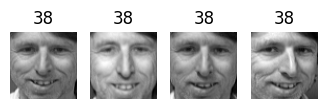

Clúster 1 (Total imágenes: 2) 


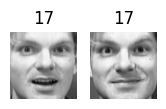

Clúster 2 (Total imágenes: 2) 


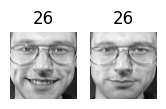

Clúster 3 (Total imágenes: 4) 


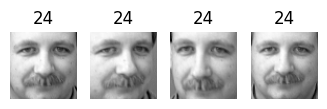

Clúster 4 (Total imágenes: 3) 


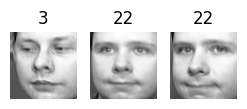

Clúster 5 (Total imágenes: 5) 


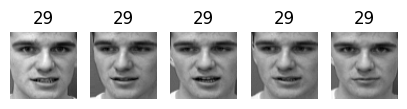

Clúster 6 (Total imágenes: 1) 


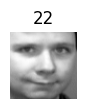

Clúster 7 (Total imágenes: 1) 


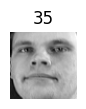

Clúster 8 (Total imágenes: 2) 


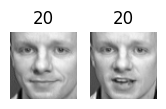

Clúster 9 (Total imágenes: 1) 


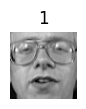

In [45]:
# Obtenemos las etiquetas de los clústeres asignadas a cada imagen de entrenamiento
labels = best_model.labels_

# Recorremos los primeros 10 clústeres
for cluster_id in range(10):
    # Buscamos los índices de las imágenes que pertenecen a este clúster
    indices = np.where(labels == cluster_id)[0]
    
    # Seleccionamos las imágenes originales (X_train) y sus etiquetas reales (y_train)
    faces_to_plot = X_train[indices[:10]]
    real_labels = y_train[indices[:10]]
    
    print(f"Clúster {cluster_id} (Total imágenes: {len(indices)}) ")
    if len(indices) > 0:
        plot_faces(faces_to_plot, real_labels)
    else:
        print("Clúster vacío")

## **#2**


### #2.1


Continuando con el conjunto de datos de caras Olivetti, entrena un clasificador para predecir qué persona está representada en cada imagen, y evalúalo en el conjunto de validación. Utiliza un RandomForest con 150 submodelos o estimadores (y el resto de hiperparámetros déjalos a su valor por defecto)

In [46]:
# Instanciar el modelo con 150 estimadores

rf_clf = RandomForestClassifier(n_estimators=150, random_state=42)

# Entrenar el modelo

rf_clf.fit(X_train, y_train)

# 3. Predecir en el conjunto de validación
y_pred_val = rf_clf.predict(X_val)

# 4. Evaluar el rendimiento
accuracy = accuracy_score(y_val, y_pred_val)

print(f"Precisión (Accuracy) en el conjunto de validación: {accuracy:.2%}")
print("\nInforme de clasificación (resumen):")
print(classification_report(y_val, y_pred_val))

Precisión (Accuracy) en el conjunto de validación: 97.50%

Informe de clasificación (resumen):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         1
           1       1.00      1.00      1.00         1
           2       1.00      1.00      1.00         1
           3       1.00      1.00      1.00         1
           4       1.00      1.00      1.00         1
           5       1.00      1.00      1.00         1
           6       1.00      1.00      1.00         1
           7       1.00      1.00      1.00         1
           8       1.00      1.00      1.00         1
           9       1.00      1.00      1.00         1
          10       1.00      1.00      1.00         1
          11       1.00      1.00      1.00         1
          12       1.00      1.00      1.00         1
          13       1.00      1.00      1.00         1
          14       1.00      1.00      1.00         1
          15       1.00      1.00      1

c:\Users\ivanm\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\ivanm\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\ivanm\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mo

### #2.2

Utiliza K-Means como una herramienta de reducción de dimensionalidad y entrena un clasificador en el conjunto reducido. Para ello emplea el método transform de manera que ahora las features de entrada sean las distancias de cada punto a los centroides del modelo "best_model" de la parte anterior. Por ejemplo:
```python
X_train_reduced = best_model.transform(X_train_pca) 
```


Ojo lo tienes que aplicar a todos los datasets. Luego vuelve a entrenar un RandomForest sobre este dataset y evalualo contra el dataset de validacion.

In [47]:
X_train_reduced = best_model.transform(X_train_pca)
X_val_reduced = best_model.transform(X_val_pca)
X_test_reduced = best_model.transform(X_test_pca)

# Entrenamos un nuevo RandomForest sobre este espacio de distancias
rf_clf_reduced = RandomForestClassifier(n_estimators=150, random_state=42)
rf_clf_reduced.fit(X_train_reduced, y_train)

# Evaluamos en el conjunto de validación
y_pred_val_reduced = rf_clf_reduced.predict(X_val_reduced)
accuracy_reduced = accuracy_score(y_val, y_pred_val_reduced)

print(f"Número de nuevas features (K): {X_train_reduced.shape[1]}")
print(f"Precisión en validación con K-Means como reducción: {accuracy_reduced:.2%}")

Número de nuevas features (K): 140
Precisión en validación con K-Means como reducción: 85.00%


### #2.3 EXTRA VOLUNTARIO

Busca el número de clusters k que generen un algoritmo kmeans que a su vez sus distancias a los centroides sean las features de un clasificador RandomForest y que permita al clasificador obtener el mejor rendimiento: ¿Qué rendimiento puedes alcanzar? (en terminos de Accuracy)

In [48]:
from sklearn.pipeline import Pipeline

best_accuracy = 0
best_k_for_rf = 0
results = []

# Probamos diferentes valores de K para ver cuál ayuda más al Random Forest
k_range = range(20, 160, 20) 

for k in k_range:
    # 1. Creamos el modelo K-Means con el k actual
    kmeans_features = KMeans(n_clusters=k, n_init=10, random_state=42)
    
    # 2. Transformamos los datos a distancias de centroides
    X_train_k = kmeans_features.fit_transform(X_train_pca)
    X_val_k = kmeans_features.transform(X_val_pca)
    
    # 3. Entrenamos el clasificador sobre esas distancias
    rf = RandomForestClassifier(n_estimators=150, random_state=42)
    rf.fit(X_train_k, y_train)
    
    # 4. Evaluamos
    current_acc = rf.score(X_val_k, y_val)
    results.append(current_acc)
    
    print(f"K={k} -> Accuracy del Clasificador: {current_acc:.4f}")
    
    if current_acc > best_accuracy:
        best_accuracy = current_acc
        best_k_for_rf = k

print(f"\nResultado Final: El mejor rendimiento es {best_accuracy:.2%} con K={best_k_for_rf}")

K=20 -> Accuracy del Clasificador: 0.6250
K=40 -> Accuracy del Clasificador: 0.7750
K=60 -> Accuracy del Clasificador: 0.8250
K=80 -> Accuracy del Clasificador: 0.8500
K=100 -> Accuracy del Clasificador: 0.7750
K=120 -> Accuracy del Clasificador: 0.8250
K=140 -> Accuracy del Clasificador: 0.8500

Resultado Final: El mejor rendimiento es 85.00% con K=80
